<a href="https://colab.research.google.com/github/Akira006/orion-fl-dr-research/blob/main/notebooks/Multiclient/exp1_centralized_multiclient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sat May  2 01:04:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# =========================
# CELL 1A — MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================
# CELL 1B — IMPORTS + CONFIG
# =========================
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# PATH CONFIG — PROJECT
# =========================
PROJECT_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research"

DATASET_NAME    = "MultiClient"
EXPERIMENT_NAME = "exp1_baseline"
MODEL_NAME      = "mobilenet"

BASE_RESULT_DIR = os.path.join(PROJECT_DIR, "results", DATASET_NAME, EXPERIMENT_NAME, MODEL_NAME)
MODELS_DIR      = os.path.join(BASE_RESULT_DIR, "models")
LOGS_DIR        = os.path.join(BASE_RESULT_DIR, "logs")
FIGURES_DIR     = os.path.join(BASE_RESULT_DIR, "figures")

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(LOGS_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# =========================
# PATH CONFIG — CLIENTS (Data Sources)
# =========================
# Client 1 — APTOS 2019  (label dari NPZ internal)
APTOS_NPZ_PATH = "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz"

# Client 2 — DDR
DDR_NPZ_PATH   = "/content/drive/MyDrive/S-Class/Orion/OrionFL/DDR_Dataset/DDR_dataset_224.npz"
DDR_LABEL_PATH = "/content/drive/MyDrive/S-Class/Orion/OrionFL/DDR_Dataset/DR_grading.csv"

# Client 3 — EyePACS
EYEPACS_NPZ_PATH   = "/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/EyePACS_dataset_224.npz"
EYEPACS_LABEL_PATH = "/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/trainLabels.csv"

# =========================
# TRAINING CONFIG
# =========================
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 20

LEARNING_RATE_STAGE1 = 1e-3
LEARNING_RATE_STAGE2 = 1e-6

NUM_CLASSES            = 5
UNFREEZE_LAST_N_LAYERS = 10

# =========================
# DEBUG INFO
# =========================
print("TensorFlow version:", tf.__version__)
print()
print("PROJECT_DIR exists     :", os.path.exists(PROJECT_DIR))
print("BASE_RESULT_DIR        :", BASE_RESULT_DIR)
print()
print("APTOS_NPZ exists       :", os.path.exists(APTOS_NPZ_PATH))
print("DDR_NPZ exists         :", os.path.exists(DDR_NPZ_PATH))
print("DDR_LABEL exists       :", os.path.exists(DDR_LABEL_PATH))
print("EYEPACS_NPZ exists     :", os.path.exists(EYEPACS_NPZ_PATH))
print("EYEPACS_LABEL exists   :", os.path.exists(EYEPACS_LABEL_PATH))
print()
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("tf     :", tf.__version__)
print("\nAll imports OK.")

TensorFlow version: 2.20.0

PROJECT_DIR exists     : True
BASE_RESULT_DIR        : /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet

APTOS_NPZ exists       : True
DDR_NPZ exists         : True
DDR_LABEL exists       : True
EYEPACS_NPZ exists     : True
EYEPACS_LABEL exists   : True

numpy  : 2.0.2
pandas : 2.2.2
tf     : 2.20.0

All imports OK.


In [4]:
# =========================
# CELL 2 — SANITY CHECK SEMUA NPZ
# =========================
def check_npz(label, path):
    print(f"── {label} ──")
    if not os.path.exists(path):
        print(f"  [ERROR] File tidak ditemukan: {path}")
        return
    data = np.load(path, allow_pickle=True)
    print(f"  Keys   : {data.files}")
    for k in data.files:
        arr = data[k]
        try:
            print(f"  {k:12s}: shape={arr.shape}, dtype={arr.dtype}")
        except Exception:
            print(f"  {k:12s}: type={type(arr)}")
    print()

check_npz("APTOS",   APTOS_NPZ_PATH)
check_npz("DDR",     DDR_NPZ_PATH)
check_npz("EyePACS", EYEPACS_NPZ_PATH)

── APTOS ──
  Keys   : ['images', 'labels']
  images      : shape=(3662, 224, 224, 3), dtype=uint8
  labels      : shape=(3662,), dtype=int64

── DDR ──
  Keys   : ['X', 'y', 'filenames']
  X           : shape=(12522, 224, 224, 3), dtype=float32
  y           : shape=(12522,), dtype=int64
  filenames   : shape=(12522,), dtype=<U21

── EyePACS ──
  Keys   : ['images', 'labels', 'filenames']
  images      : shape=(35126, 224, 224, 3), dtype=uint8
  labels      : shape=(35126,), dtype=int64
  filenames   : shape=(35126,), dtype=<U11



In [5]:
# =========================
# CELL 3 — LOAD CLIENT 1: APTOS
# =========================
# NPZ keys: ['images', 'labels'] — label diambil dari NPZ internal
aptos_data = np.load(APTOS_NPZ_PATH, allow_pickle=True)
X_aptos    = aptos_data["images"]          # uint8
y_aptos    = aptos_data["labels"].astype(np.int64)

assert len(X_aptos) == len(y_aptos), (
    f"APTOS: jumlah images ({len(X_aptos)}) != jumlah label ({len(y_aptos)})."
)

print("APTOS — X shape:", X_aptos.shape, "| y shape:", y_aptos.shape)
print("Label distribution:")
print(pd.Series(y_aptos).value_counts().sort_index())
print()

APTOS — X shape: (3662, 224, 224, 3) | y shape: (3662,)
Label distribution:
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64



In [6]:
# =========================
# CELL 4 — LOAD CLIENT 2: DDR
# =========================
# NPZ keys: ['X', 'y', 'filenames'] — label diambil dari external CSV (DR_grading.csv)
ddr_data = np.load(DDR_NPZ_PATH, allow_pickle=True)
print("DDR NPZ keys:", ddr_data.files)
X_ddr    = ddr_data["X"]        # uint8

assert os.path.exists(DDR_LABEL_PATH), f"Label CSV tidak ditemukan: {DDR_LABEL_PATH}"
ddr_label_df = pd.read_csv(DDR_LABEL_PATH)
y_ddr        = ddr_label_df["diagnosis"].values.astype(np.int64)

assert len(X_ddr) == len(y_ddr), (
    f"DDR: jumlah images ({len(X_ddr)}) != jumlah label ({len(y_ddr)}). "
    "Cek ulang urutan CSV vs NPZ."
)

print("DDR — X shape:", X_ddr.shape, "| y shape:", y_ddr.shape)
print("Label distribution:")
print(pd.Series(y_ddr).value_counts().sort_index())
print()

DDR NPZ keys: ['X', 'y', 'filenames']
DDR — X shape: (12522, 224, 224, 3) | y shape: (12522,)
Label distribution:
0    6266
1     630
2    4477
3     236
4     913
Name: count, dtype: int64



In [7]:
# =========================
# CELL 5 — LOAD CLIENT 3: EyePACS
# =========================
# NPZ keys: ['images', 'labels', 'filenames'] — label dari CSV (bukan internal NPZ)
eyepacs_data = np.load(EYEPACS_NPZ_PATH, allow_pickle=True)
X_eyepacs    = eyepacs_data["images"]   # uint8

assert os.path.exists(EYEPACS_LABEL_PATH), f"Label CSV tidak ditemukan: {EYEPACS_LABEL_PATH}"
label_df     = pd.read_csv(EYEPACS_LABEL_PATH)
y_eyepacs    = label_df["level"].values.astype(np.int64)

assert len(X_eyepacs) == len(y_eyepacs), (
    f"Jumlah images ({len(X_eyepacs)}) != jumlah label ({len(y_eyepacs)}). "
    "Cek ulang urutan CSV vs NPZ."
)

print("EyePACS — X shape:", X_eyepacs.shape, "| y shape:", y_eyepacs.shape)
print("Label distribution:")
print(pd.Series(y_eyepacs).value_counts().sort_index())
print()

EyePACS — X shape: (35126, 224, 224, 3) | y shape: (35126,)
Label distribution:
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64



In [8]:
# =========================
# CELL 6 — POOL SEMUA DATA (APTOS + DDR + EyePACS)
# =========================
X_all = np.concatenate([X_aptos, X_ddr, X_eyepacs], axis=0)
y_all = np.concatenate([y_aptos, y_ddr, y_eyepacs], axis=0)

# Tambahkan source tag untuk analisis per-dataset nanti (opsional, disimpan sebagai referensi)
source_all = (
    ["APTOS"]   * len(y_aptos)   +
    ["DDR"]     * len(y_ddr)     +
    ["EyePACS"] * len(y_eyepacs)
)
source_all = np.array(source_all)

print("=" * 50)
print("POOLED DATASET SUMMARY")
print("=" * 50)
print(f"APTOS    : {len(y_aptos):>7,} samples")
print(f"DDR      : {len(y_ddr):>7,} samples")
print(f"EyePACS  : {len(y_eyepacs):>7,} samples")
print(f"{'TOTAL':9}: {len(y_all):>7,} samples")
print()
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print()
print("Overall label distribution (pooled):")
vc = pd.Series(y_all).value_counts().sort_index()
for cls, cnt in vc.items():
    print(f"  Class {cls}: {cnt:>6,}  ({cnt/len(y_all)*100:.1f}%)")

POOLED DATASET SUMMARY
APTOS    :   3,662 samples
DDR      :  12,522 samples
EyePACS  :  35,126 samples
TOTAL    :  51,310 samples

X_all shape: (51310, 224, 224, 3)
y_all shape: (51310,)

Overall label distribution (pooled):
  Class 0: 33,881  (66.0%)
  Class 1:  3,443  (6.7%)
  Class 2: 10,768  (21.0%)
  Class 3:  1,302  (2.5%)
  Class 4:  1,916  (3.7%)


In [9]:
# =========================
# CELL 7 — GLOBAL TRAIN/VAL/TEST SPLIT (70:15:15) — STRATIFIED
# =========================

# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp, src_train, src_temp = train_test_split(
    X_all, y_all, source_all,
    test_size=0.30,
    random_state=SEED,
    stratify=y_all
)

# Step 2: temp 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test, src_val, src_test = train_test_split(
    X_temp, y_temp, src_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train shape :", X_train.shape, y_train.shape)
print("Val shape   :", X_val.shape,   y_val.shape)
print("Test shape  :", X_test.shape,  y_test.shape)

print("\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nVal label distribution:")
print(pd.Series(y_val).value_counts().sort_index())
print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

# Source breakdown di test set (untuk analisis domain nanti)
print("\nTest set — source breakdown:")
print(pd.Series(src_test).value_counts())

Train shape : (35917, 224, 224, 3) (35917,)
Val shape   : (7696, 224, 224, 3) (7696,)
Test shape  : (7697, 224, 224, 3) (7697,)

Train label distribution:
0    23717
1     2410
2     7538
3      911
4     1341
Name: count, dtype: int64

Val label distribution:
0    5082
1     516
2    1615
3     196
4     287
Name: count, dtype: int64

Test label distribution:
0    5082
1     517
2    1615
3     195
4     288
Name: count, dtype: int64

Test set — source breakdown:
EyePACS    5238
DDR        1901
APTOS       558
Name: count, dtype: int64


In [10]:
# =========================
# CELL 8 — PREPROCESS DATA (MobileNetV2 preprocess_input)
# =========================
X_train = preprocess_input(X_train.astype("float32"))
X_val   = preprocess_input(X_val.astype("float32"))
X_test  = preprocess_input(X_test.astype("float32"))

print("Preprocessing done.")
print("X_train dtype:", X_train.dtype, "| range sample:", X_train[0].min().round(2), "to", X_train[0].max().round(2))
print("X_val   dtype:", X_val.dtype)
print("X_test  dtype:", X_test.dtype)

Preprocessing done.
X_train dtype: float32 | range sample: -1.0 to 1.0
X_val   dtype: float32
X_test  dtype: float32


In [11]:
# =========================
# CELL 9 — COMPUTE CLASS WEIGHTS (dari pooled train set)
# =========================
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {int(cls): float(w) for cls, w in zip(classes, class_weights_array)}

print("Class weights (pooled train):")
for k, v in class_weights.items():
    print(f"  Class {k}: {v:.4f}")

Class weights (pooled train):
  Class 0: 0.3029
  Class 1: 2.9807
  Class 2: 0.9530
  Class 3: 7.8852
  Class 4: 5.3567


In [12]:
# =========================
# CELL 10 — BUILD TF DATASETS + LIGHT AUGMENTATION
# =========================
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="light_augmentation")

def augment_fn(x, y):
    x = data_augmentation(x, training=True)
    return x, y

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train), seed=SEED)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("train_ds ready  — batches:", len(train_ds))
print("val_ds   ready  — batches:", len(val_ds))
print("test_ds  ready  — batches:", len(test_ds))

train_ds ready  — batches: 1123
val_ds   ready  — batches: 241
test_ds  ready  — batches: 241


In [13]:
# =========================
# CELL 11 — DEFINE MODEL BUILDER
# =========================
def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=5):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

In [14]:
# =========================
# CELL 12 — BUILD MODEL
# =========================
model, base_model = build_mobilenetv2_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# =========================
# CELL 13 — COMPILE + TRAIN STAGE 1 (Frozen Backbone)
# =========================
STAGE1_BEST_PATH = os.path.join(MODELS_DIR, "best_mobilenetv2_stage1.keras")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE1),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_stage1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=STAGE1_BEST_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Stage 1 compile done.")

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks_stage1,
    verbose=1
)

Stage 1 compile done.
Epoch 1/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3062 - loss: 1.6963
Epoch 1: val_loss improved from None to 1.25662, saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/models/best_mobilenetv2_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/models/best_mobilenetv2_stage1.keras
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 125s 78ms/step - accuracy: 0.3193 - loss: 1.5973 - val_accuracy: 0.4367 - val_loss: 1.2566 - learning_rate: 0.0010
Epoch 2/20
1121/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3494 - loss: 1.4866
Epoch 2: val_loss did not improve from 1.25662
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 50s 44ms/step - accuracy: 0.3408 - loss: 1.4914 - val_accuracy: 0.4701 - val_loss: 1.3090 - learning_rate: 0.0010
Epoch 3/20
1122/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0

In [16]:
# =========================
# CELL 14 — UNFREEZE LAST N LAYERS
# =========================
base_model.trainable = True

# Freeze sebagian besar layer
for layer in base_model.layers[:-UNFREEZE_LAST_N_LAYERS]:
    layer.trainable = False

# Unfreeze N layer terakhir
for layer in base_model.layers[-UNFREEZE_LAST_N_LAYERS:]:
    layer.trainable = True

# BatchNorm tetap dibekukan agar stabil
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Trainable layers in base_model: {trainable_count} / {len(base_model.layers)}")

Trainable layers in base_model: 6 / 154


In [17]:
# =========================
# CELL 15 — COMPILE + TRAIN STAGE 2 (Fine-Tuning)
# =========================
STAGE2_BEST_PATH = os.path.join(MODELS_DIR, "best_mobilenetv2_finetune.keras")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE2),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=STAGE2_BEST_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Stage 2 compile done.")

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights,
    callbacks=callbacks_stage2,
    verbose=1
)

Stage 2 compile done.
Epoch 1/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4069 - loss: 1.3809
Epoch 1: val_loss improved from None to 1.24301, saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/models/best_mobilenetv2_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/models/best_mobilenetv2_finetune.keras
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.3903 - loss: 1.3645 - val_accuracy: 0.4313 - val_loss: 1.2430 - learning_rate: 1.0000e-06
Epoch 2/20
1121/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3825 - loss: 1.3471
Epoch 2: val_loss did not improve from 1.24301
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 50s 44ms/step - accuracy: 0.3789 - loss: 1.3518 - val_accuracy: 0.4335 - val_loss: 1.2551 - learning_rate: 1.0000e-06
Epoch 3/20
1122/1123 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - 

In [18]:
# =========================
# CELL 16 — SAVE FINAL MODEL
# =========================
FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "mobilenetv2_multiclient_final.keras")
model.save(FINAL_MODEL_PATH)
print("Model saved to:", FINAL_MODEL_PATH)

Model saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/models/mobilenetv2_multiclient_final.keras


In [19]:
# =========================
# CELL 17 — QUICK RESULT SUMMARY
# =========================
stage1_best_val_acc  = max(history_stage1.history.get("val_accuracy", [None]))
stage1_best_val_loss = min(history_stage1.history.get("val_loss",     [None]))
stage2_best_val_acc  = max(history_stage2.history.get("val_accuracy", [None]))
stage2_best_val_loss = min(history_stage2.history.get("val_loss",     [None]))

final_train_acc  = history_stage2.history.get("accuracy",     [None])[-1]
final_val_acc    = history_stage2.history.get("val_accuracy", [None])[-1]
final_train_loss = history_stage2.history.get("loss",         [None])[-1]
final_val_loss   = history_stage2.history.get("val_loss",     [None])[-1]

print("\n" + "="*60)
print("MULTICLIENT BASELINE TRAINING FINISHED")
print("="*60)
print(f"Best Stage 1 Val Accuracy : {stage1_best_val_acc:.4f}" if stage1_best_val_acc else "Best Stage 1 Val Accuracy : None")
print(f"Best Stage 2 Val Accuracy : {stage2_best_val_acc:.4f}" if stage2_best_val_acc else "Best Stage 2 Val Accuracy : None")
print(f"Final Train Accuracy      : {final_train_acc:.4f}"     if final_train_acc     else "Final Train Accuracy      : None")
print(f"Final Val Accuracy        : {final_val_acc:.4f}"       if final_val_acc       else "Final Val Accuracy        : None")
print(f"Train size : {len(X_train):,}")
print(f"Val size   : {len(X_val):,}")
print(f"Test size  : {len(X_test):,}")
print("="*60)


MULTICLIENT BASELINE TRAINING FINISHED
Best Stage 1 Val Accuracy : 0.5446
Best Stage 2 Val Accuracy : 0.4335
Final Train Accuracy      : 0.3741
Final Val Accuracy        : 0.4219
Train size : 35,917
Val size   : 7,696
Test size  : 7,697


In [20]:
# =========================
# CELL 18 — SAVE RUN SUMMARY METRICS
# =========================
summary_metrics = {
    "experiment_name"       : EXPERIMENT_NAME,
    "dataset_name"          : DATASET_NAME,
    "model_name"            : MODEL_NAME,
    "clients"               : ["APTOS", "DDR", "EyePACS"],
    "client_sizes"          : {
        "APTOS"  : int(len(y_aptos)),
        "DDR"    : int(len(y_ddr)),
        "EyePACS": int(len(y_eyepacs)),
        "total"  : int(len(y_all))
    },
    "split_type"            : "global_pooled_70_15_15",
    "train_size"            : int(len(X_train)),
    "val_size"              : int(len(X_val)),
    "test_size"             : int(len(X_test)),
    "stage1_best_val_accuracy" : float(stage1_best_val_acc)  if stage1_best_val_acc  else None,
    "stage1_best_val_loss"     : float(stage1_best_val_loss) if stage1_best_val_loss else None,
    "stage2_best_val_accuracy" : float(stage2_best_val_acc)  if stage2_best_val_acc  else None,
    "stage2_best_val_loss"     : float(stage2_best_val_loss) if stage2_best_val_loss else None,
    "final_train_accuracy"     : float(final_train_acc)  if final_train_acc  else None,
    "final_val_accuracy"       : float(final_val_acc)    if final_val_acc    else None,
    "final_train_loss"         : float(final_train_loss) if final_train_loss else None,
    "final_val_loss"           : float(final_val_loss)   if final_val_loss   else None,
}

summary_path = os.path.join(LOGS_DIR, "run_summary_metrics.json")
with open(summary_path, "w") as f:
    json.dump(summary_metrics, f, indent=4)

print("Saved:", summary_path)
print(json.dumps(summary_metrics, indent=4))

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/logs/run_summary_metrics.json
{
    "experiment_name": "exp1_baseline",
    "dataset_name": "MultiClient",
    "model_name": "mobilenet",
    "clients": [
        "APTOS",
        "DDR",
        "EyePACS"
    ],
    "client_sizes": {
        "APTOS": 3662,
        "DDR": 12522,
        "EyePACS": 35126,
        "total": 51310
    },
    "split_type": "global_pooled_70_15_15",
    "train_size": 35917,
    "val_size": 7696,
    "test_size": 7697,
    "stage1_best_val_accuracy": 0.5445685982704163,
    "stage1_best_val_loss": 1.1526325941085815,
    "stage2_best_val_accuracy": 0.4334719479084015,
    "stage2_best_val_loss": 1.2430078983306885,
    "final_train_accuracy": 0.3741125464439392,
    "final_val_accuracy": 0.4219074845314026,
    "final_train_loss": 1.3464858531951904,
    "final_val_loss": 1.2685672044754028
}


In [21]:
# =========================
# CELL 19 — BUILD FINAL PREDICTION OBJECTS
# =========================
test_probs = model.predict(test_ds, verbose=1)
test_preds = np.argmax(test_probs, axis=1)

y_true = np.array(y_test)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)
print("Unique labels in y_true:", np.unique(y_true))

241/241 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step
y_true shape: (7697,)
y_pred shape: (7697,)
y_prob shape: (7697, 5)
Unique labels in y_true: [0 1 2 3 4]


In [22]:
# =========================
# CELL 20 — MAIN BASELINE SUMMARY TABLE
# =========================
acc = accuracy_score(y_true, y_pred)

precision_macro,    recall_macro,    f1_macro,    _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

y_true_bin    = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
auc_macro_ovr    = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

baseline_summary_df = pd.DataFrame([{
    "experiment_name"   : EXPERIMENT_NAME,
    "dataset_name"      : DATASET_NAME,
    "model_name"        : MODEL_NAME,
    "setup"             : "Centralized Pooled Baseline",
    "evaluation_set"    : "Test",
    "accuracy"          : acc,
    "precision_macro"   : precision_macro,
    "recall_macro"      : recall_macro,
    "f1_macro"          : f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted"   : recall_weighted,
    "f1_weighted"       : f1_weighted,
    "auc_macro_ovr"     : auc_macro_ovr,
    "auc_weighted_ovr"  : auc_weighted_ovr,
    "train_size"        : len(X_train),
    "val_size"          : len(X_val),
    "test_size"         : len(X_test),
}])

display(baseline_summary_df)

baseline_summary_df.to_csv( os.path.join(LOGS_DIR, "baseline_summary_table.csv"),  index=False)
baseline_summary_df.to_json(os.path.join(LOGS_DIR, "baseline_summary_table.json"), orient="records", indent=4)

print("Saved: baseline_summary_table.csv / .json")

,experiment_name,dataset_name,model_name,setup,evaluation_set,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro_ovr,auc_weighted_ovr,train_size,val_size,test_size
0,exp1_baseline,MultiClient,mobilenet,Centralized Pooled Baseline,Test,0.42549,0.306579,0.401634,0.264747,0.62594,0.42549,0.473738,0.728923,0.715704,35917,7696,7697


Saved: baseline_summary_table.csv / .json


In [23]:
# =========================
# CELL 21 — CLASSIFICATION REPORT
# =========================
report_text = classification_report(y_true, y_pred, digits=4)
report_dict = classification_report(y_true, y_pred, digits=4, output_dict=True)

print("Classification Report (Test Set):\n")
print(report_text)

with open(os.path.join(LOGS_DIR, "classification_report_test.txt"),  "w") as f: f.write(report_text)
with open(os.path.join(LOGS_DIR, "classification_report_test.json"), "w") as f: json.dump(report_dict, f, indent=4)

print("Saved: classification_report_test.txt / .json")

Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.8181    0.5362    0.6478      5082
           1     0.1102    0.3211    0.1641       517
           2     0.3355    0.0644    0.1081      1615
           3     0.1708    0.3538    0.2304       195
           4     0.0983    0.7326    0.1734       288

    accuracy                         0.4255      7697
   macro avg     0.3066    0.4016    0.2647      7697
weighted avg     0.6259    0.4255    0.4737      7697

Saved: classification_report_test.txt / .json


In [24]:
# =========================
# CELL 22 — LEARNING BEHAVIOUR TABLE
# =========================
learning_behaviour_df = pd.DataFrame({
    "epoch": list(range(1, len(history_stage1.history["accuracy"]) + len(history_stage2.history["accuracy"]) + 1)),
    "train_accuracy": history_stage1.history["accuracy"]     + history_stage2.history["accuracy"],
    "val_accuracy"  : history_stage1.history["val_accuracy"] + history_stage2.history["val_accuracy"],
    "train_loss"    : history_stage1.history["loss"]         + history_stage2.history["loss"],
    "val_loss"      : history_stage1.history["val_loss"]     + history_stage2.history["val_loss"],
    "stage"         : (["stage1"] * len(history_stage1.history["accuracy"]) +
                       ["stage2"] * len(history_stage2.history["accuracy"]))
})

display(learning_behaviour_df.head())

lb_csv = os.path.join(LOGS_DIR, "learning_behaviour_table.csv")
learning_behaviour_df.to_csv(lb_csv, index=False)
print("Saved:", lb_csv)

,epoch,train_accuracy,val_accuracy,train_loss,val_loss,stage
0,1,0.319320,0.436720,1.597318,1.256622,stage1
1,2,0.340814,0.470114,1.491355,1.309017,stage1
2,3,0.346382,0.411902,1.473195,1.349815,stage1
3,4,0.364173,0.348753,1.402689,1.340747,stage1
4,5,0.373584,0.544569,1.378727,1.152633,stage1


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/logs/learning_behaviour_table.csv


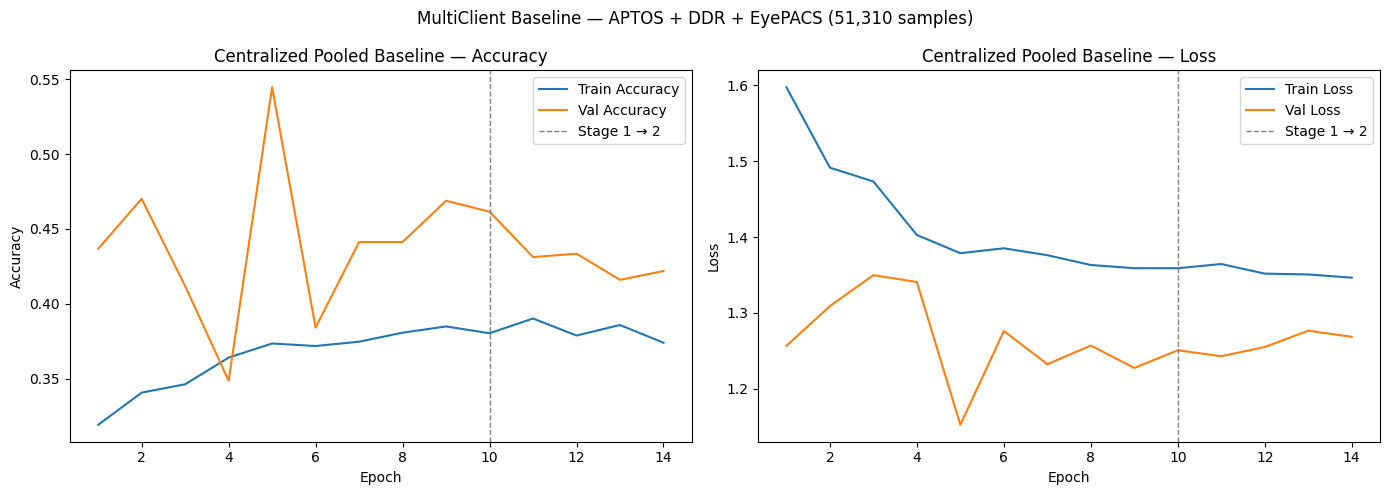

Saved: baseline_train_curves.png


In [25]:
# =========================
# CELL 23 — ACCURACY / LOSS LINE GRAPH
# =========================
epochs_all = list(range(1, len(learning_behaviour_df) + 1))
stage1_len = len(history_stage1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(epochs_all, learning_behaviour_df["train_accuracy"], label="Train Accuracy")
axes[0].plot(epochs_all, learning_behaviour_df["val_accuracy"],   label="Val Accuracy")
axes[0].axvline(x=stage1_len, color="gray", linestyle="--", linewidth=1, label="Stage 1 → 2")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Centralized Pooled Baseline — Accuracy")
axes[0].legend()

# ── Loss ──
axes[1].plot(epochs_all, learning_behaviour_df["train_loss"], label="Train Loss")
axes[1].plot(epochs_all, learning_behaviour_df["val_loss"],   label="Val Loss")
axes[1].axvline(x=stage1_len, color="gray", linestyle="--", linewidth=1, label="Stage 1 → 2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Centralized Pooled Baseline — Loss")
axes[1].legend()

plt.suptitle(f"MultiClient Baseline — APTOS + DDR + EyePACS ({len(y_all):,} samples)", fontsize=12)
plt.tight_layout()

fig.savefig(os.path.join(FIGURES_DIR, "baseline_train_curves.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: baseline_train_curves.png")

In [26]:
# =========================
# CELL 24 — PER-CLASS METRIC TABLE
# =========================
precision_cls, recall_cls, f1_cls, support_cls = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0
)

per_class_df = pd.DataFrame({
    "class"    : np.arange(NUM_CLASSES),
    "precision": precision_cls,
    "recall"   : recall_cls,
    "f1_score" : f1_cls,
    "support"  : support_cls
})

display(per_class_df)

per_class_df.to_csv( os.path.join(LOGS_DIR, "per_class_metrics.csv"),  index=False)
per_class_df.to_json(os.path.join(LOGS_DIR, "per_class_metrics.json"), orient="records", indent=4)
print("Saved: per_class_metrics.csv / .json")

,class,precision,recall,f1_score,support
0,0,0.818073,0.536206,0.647807,5082
1,1,0.110226,0.321083,0.164113,517
2,2,0.335484,0.064396,0.108052,1615
3,3,0.170792,0.353846,0.230384,195
4,4,0.098322,0.732639,0.173377,288


Saved: per_class_metrics.csv / .json


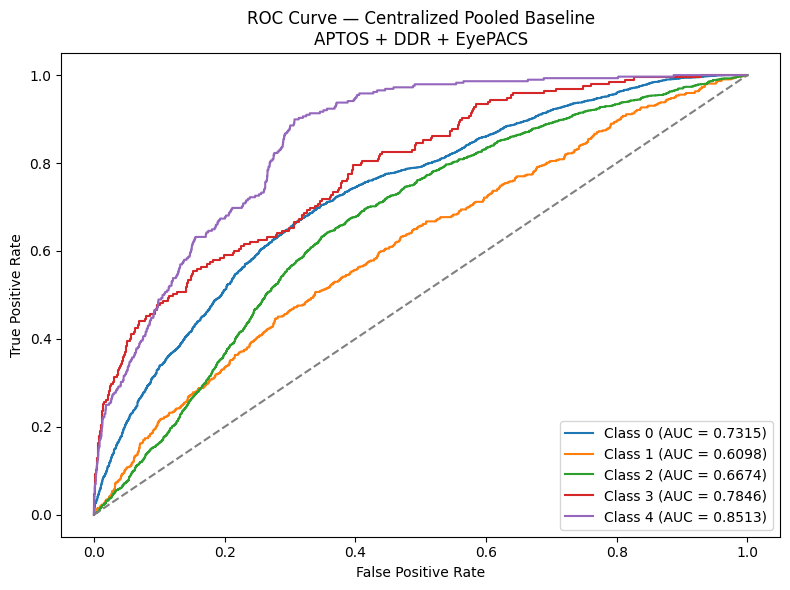

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/figures/roc_curve_baseline.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/logs/roc_auc_per_class.json


In [27]:
# =========================
# CELL 25 — ROC CURVE + AUC PER CLASS
# =========================
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

roc_auc_per_class = {}
plt.figure(figsize=(8, 6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_auc_per_class[f"class_{i}"] = float(roc_auc_val)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_val:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Centralized Pooled Baseline\nAPTOS + DDR + EyePACS")
plt.legend()
plt.tight_layout()

roc_path = os.path.join(FIGURES_DIR, "roc_curve_baseline.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

roc_json_path = os.path.join(LOGS_DIR, "roc_auc_per_class.json")
with open(roc_json_path, "w") as f:
    json.dump(roc_auc_per_class, f, indent=4)

print("Saved:", roc_path)
print("Saved:", roc_json_path)

<Figure size 700x600 with 0 Axes>

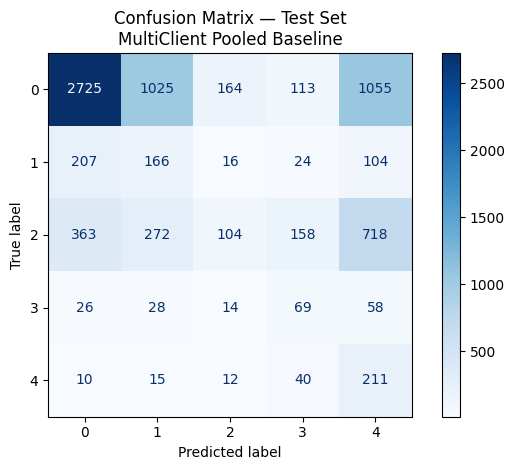

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/figures/confusion_matrix_heatmap_baseline.png
Saved: confusion_matrix_table.csv / confusion_matrix_values_test.json


In [28]:
# =========================
# CELL 26 — CONFUSION MATRIX HEATMAP
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(NUM_CLASSES))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Test Set\nMultiClient Pooled Baseline")
plt.tight_layout()

cm_path = os.path.join(FIGURES_DIR, "confusion_matrix_heatmap_baseline.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{i}"   for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)]
)
cm_df.to_csv(os.path.join(LOGS_DIR, "confusion_matrix_table.csv"))

cm_dict_path = os.path.join(LOGS_DIR, "confusion_matrix_values_test.json")
with open(cm_dict_path, "w") as f:
    json.dump({"confusion_matrix": cm.tolist()}, f, indent=4)

print("Saved:", cm_path)
print("Saved: confusion_matrix_table.csv / confusion_matrix_values_test.json")

In [30]:
# =========================
# CELL 27 — PER-DATASET TEST SET ANALYSIS
# =========================
# Analisis performa model per sumber dataset di test set
# Berguna untuk deteksi domain shift sebelum masuk FL

print("Per-Dataset Performance on Test Set")
print("=" * 55)

per_dataset_results = []

for dataset_name in ["APTOS", "DDR", "EyePACS"]:
    mask = src_test == dataset_name
    if mask.sum() == 0:
        print(f"{dataset_name}: no samples in test set")
        continue

    y_t  = y_true[mask]
    y_p  = y_pred[mask]
    y_b  = label_binarize(y_t, classes=np.arange(NUM_CLASSES))
    y_pr = y_prob[mask]

    ds_acc = accuracy_score(y_t, y_p)
    ds_p, ds_r, ds_f1, _ = precision_recall_fscore_support(
        y_t, y_p, average="macro", zero_division=0
    )

    # AUC: hanya hitung jika semua kelas hadir di subset
    try:
        ds_auc = roc_auc_score(y_b, y_pr, multi_class="ovr", average="macro")
    except ValueError:
        ds_auc = None

    auc_str = f"{ds_auc:.4f}" if ds_auc is not None else "N/A"

    per_dataset_results.append({
        "dataset"         : dataset_name,
        "n_test_samples"  : int(mask.sum()),
        "accuracy"        : round(ds_acc, 4),
        "precision_macro" : round(ds_p,   4),
        "recall_macro"    : round(ds_r,   4),
        "f1_macro"        : round(ds_f1,  4),
        "auc_macro_ovr"   : round(ds_auc, 4) if ds_auc is not None else None,
    })

    print(f"  {dataset_name:<10} | n={mask.sum():>5,} | Acc={ds_acc:.4f} | F1={ds_f1:.4f} | AUC={auc_str}")

print()
per_dataset_df = pd.DataFrame(per_dataset_results)
display(per_dataset_df)

per_dataset_df.to_csv( os.path.join(LOGS_DIR, "per_dataset_test_metrics.csv"),  index=False)
per_dataset_df.to_json(os.path.join(LOGS_DIR, "per_dataset_test_metrics.json"), orient="records", indent=4)
print("Saved: per_dataset_test_metrics.csv / .json")

Per-Dataset Performance on Test Set
  APTOS      | n=  558 | Acc=0.6219 | F1=0.4563 | AUC=0.8557
  DDR        | n=1,901 | Acc=0.0726 | F1=0.0271 | AUC=0.5367
  EyePACS    | n=5,238 | Acc=0.5326 | F1=0.3202 | AUC=0.7286



,dataset,n_test_samples,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr
0,APTOS,558,0.6219,0.5053,0.5399,0.4563,0.8557
1,DDR,1901,0.0726,0.0145,0.2000,0.0271,0.5367
2,EyePACS,5238,0.5326,0.3260,0.4076,0.3202,0.7286


Saved: per_dataset_test_metrics.csv / .json


In [31]:
# =========================
# CELL 28 — RESULT PACKAGE FOR FUTURE COMPARISON (FL vs Centralized)
# =========================
comparison_row = {
    "method"           : "Centralized_Pooled",
    "model"            : MODEL_NAME,
    "dataset"          : DATASET_NAME,
    "clients"          : ["APTOS", "DDR", "EyePACS"],
    "accuracy"         : float(acc),
    "precision_macro"  : float(precision_macro),
    "recall_macro"     : float(recall_macro),
    "f1_macro"         : float(f1_macro),
    "auc_macro_ovr"    : float(auc_macro_ovr),
    "train_size"       : int(len(X_train)),
    "val_size"         : int(len(X_val)),
    "test_size"        : int(len(X_test)),
    "total_samples"    : int(len(y_all)),
    "notes"            : "Pooled centralized baseline (APTOS+DDR+EyePACS), global 70:15:15 stratified split. Upper-bound reference for FL comparison."
}

comparison_row_path = os.path.join(LOGS_DIR, "comparison_ready_baseline.json")
with open(comparison_row_path, "w") as f:
    json.dump(comparison_row, f, indent=4)

print("Saved:", comparison_row_path)
print(json.dumps(comparison_row, indent=4))

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp1_baseline/mobilenet/logs/comparison_ready_baseline.json
{
    "method": "Centralized_Pooled",
    "model": "mobilenet",
    "dataset": "MultiClient",
    "clients": [
        "APTOS",
        "DDR",
        "EyePACS"
    ],
    "accuracy": 0.42549045082499676,
    "precision_macro": 0.3065793650069811,
    "recall_macro": 0.40163414354723315,
    "f1_macro": 0.26474654951996623,
    "auc_macro_ovr": 0.7289234123446431,
    "train_size": 35917,
    "val_size": 7696,
    "test_size": 7697,
    "total_samples": 51310,
    "notes": "Pooled centralized baseline (APTOS+DDR+EyePACS), global 70:15:15 stratified split. Upper-bound reference for FL comparison."
}
